<a href="https://colab.research.google.com/github/dhammdiplokhande1595/Project_1/blob/main/analysis_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("Salary_Data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [4]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [5]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [6]:
df.isnull().sum().sum()

np.int64(17)

In [7]:
num = df.select_dtypes(include=["int64","float64"])

In [8]:
cat = df.select_dtypes(include=["object"])

In [9]:
cat.columns

Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

In [10]:
# numerical columns → mean
num_cols = ['Age','Years of Experience','Salary']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# categorical columns → mode
cat_cols = ['Gender','Education Level','Job Title']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# verify
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [11]:
display(df.head())

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [12]:
# Define categorical columns to be label encoded
cat_cols_to_encode = ['Gender', 'Education Level', 'Job Title']
X = df.drop('Salary', axis=1)
y = df['Salary']
print("Independent Variables (X):")
display(X.head())

print("\nDependent Variable (y):")
display(y.head())

Independent Variables (X):


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0
1,28.0,Female,Master's,Data Analyst,3.0
2,45.0,Male,PhD,Senior Manager,15.0
3,36.0,Female,Bachelor's,Sales Associate,7.0
4,52.0,Male,Master's,Director,20.0



Dependent Variable (y):


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [13]:
cat_cols_to_encode = ['Gender', 'Education Level', 'Job Title']
for col in cat_cols_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Independent Variables (X) after Label Encoding:")
display(X.head())

Independent Variables (X) after Label Encoding:


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,177,5.0
1,28.0,0,3,18,3.0
2,45.0,1,5,145,15.0
3,36.0,0,0,116,7.0
4,52.0,1,3,26,20.0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (5363, 5)
Shape of X_test: (1341, 5)
Shape of y_train: (5363,)
Shape of y_test: (1341,)


In [15]:
# Initialize, train, and evaluate Linear Regression
print("Training Linear Regression...")
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)
y_pred_lr = linear_regression_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print(f"Linear Regression - R2 Score: {r2_lr:.4f}, MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}")

Training Linear Regression...
Linear Regression - R2 Score: 0.6658, MAE: 23736.65, MSE: 892668414.69


In [16]:
# Initialize, train, and evaluate Random Forest Regressor
print("Training Random Forest...")
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest - R2 Score: {r2_rf:.4f}, MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}")

Training Random Forest...
Random Forest - R2 Score: 0.9756, MAE: 3152.26, MSE: 65085758.85


In [17]:
# Initialize, train, and evaluate Gradient Boosting Regressor
print("Training Gradient Boosting...")
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train, y_train)
y_pred_gb = gradient_boosting_model.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)

print(f"Gradient Boosting - R2 Score: {r2_gb:.4f}, MAE: {mae_gb:.2f}, MSE: {mse_gb:.2f}")

Training Gradient Boosting...
Gradient Boosting - R2 Score: 0.9349, MAE: 9558.94, MSE: 173977023.55


In [18]:
# Initialize, train, and evaluate Support Vector Regressor
print("Training Support Vector Regressor...")
svr_model = SVR()
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)

print(f"Support Vector Regressor - R2 Score: {r2_svr:.4f}, MAE: {mae_svr:.2f}, MSE: {mse_svr:.2f}")

Training Support Vector Regressor...
Support Vector Regressor - R2 Score: 0.0014, MAE: 44711.98, MSE: 2666827729.94


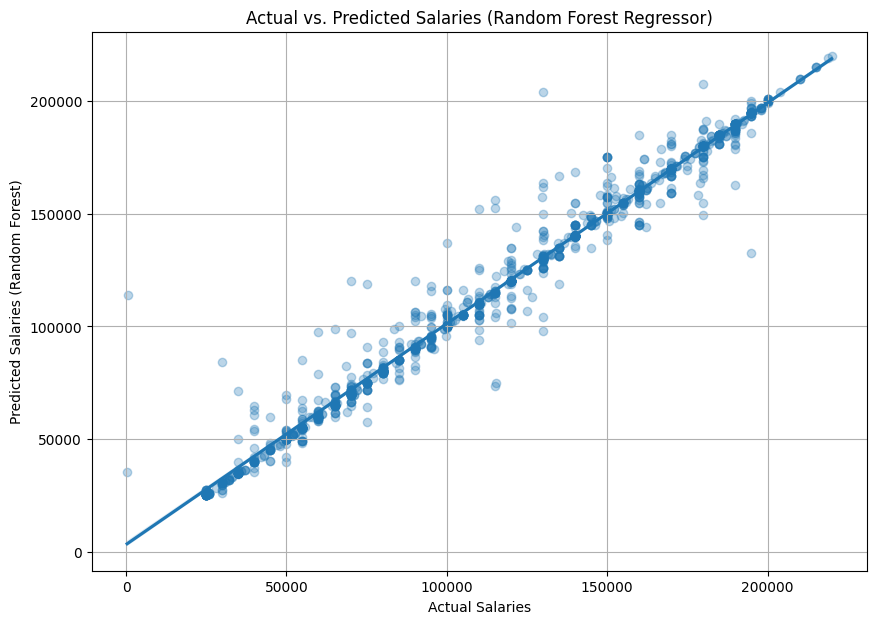

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries (Random Forest)')
plt.title('Actual vs. Predicted Salaries (Random Forest Regressor)')
plt.grid(True)
plt.show()

In [21]:
import joblib

# Save the best performing model (Random Forest Regressor)
model_filename = 'random_forest_regressor_model.joblib'
joblib.dump(random_forest_model, model_filename)

print(f"Random Forest Regressor model saved to {model_filename}")

Random Forest Regressor model saved to random_forest_regressor_model.joblib
